In [1]:
# Ячейка 1: Импорт библиотек и настройка окружения
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Отключение параллелизма для избежания deadlocks 

import torch
from torch.utils.data import DataLoader
import pandas as pd
from datasets import Dataset, DatasetDict
from tokenizers import Tokenizer, models, pre_tokenizers, trainers
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import torch.nn as nn
import torchmetrics

print("Импортированы библиотеки и отключен параллелизм в tokenizers")

# Ячейка 2: Загрузка новых данных с проверкой
def load_new_data(ds_path="text_with_morph_features.csv"):
    try:
        # Чтение CSV с разделителем и проверкой структуры
        df = pd.read_csv(ds_path, sep=",")
        print("Первые строки данных:")
        print(df.head())  # Диагностика загрузки данных
        
        # Проверка наличия необходимых столбцов 
        required_columns = ['text', 'type', 'normalized_text', 'tokens']
        if not all(col in df.columns for col in required_columns):
            raise ValueError(f"CSV должен содержать столбцы: {required_columns}")
        
        # Удаление пустых строк 
        df = df[df['normalized_text'].notna() & (df['normalized_text'] != '')]
        print(f"Очищено {len(df)} строк после удаления пустых текстов")
        
        # Выборка необходимых столбцов
        df = df[['normalized_text', 'type']]
        df.columns = ['text', 'label']
        
        # Преобразование в Dataset
        dataset = Dataset.from_pandas(df)
        print(f"Исходный датасет содержит {len(dataset)} записей")
        
        return dataset
    except FileNotFoundError:
        raise FileNotFoundError(f"Файл {ds_path} не найден. Проверьте путь к файлу")
    except Exception as e:
        raise RuntimeError(f"Ошибка при загрузке данных: {str(e)}")

dataset = load_new_data()

/home/artyom/itmo_labs/itmo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Импортированы библиотеки и отключен параллелизм в tokenizers
Первые строки данных:
                                                text  type  \
0  @first_timee хоть я и школота, но поверь, у на...     1   
1  Да, все-таки он немного похож на него. Но мой ...     1   
2  RT @KatiaCheh: Ну ты идиотка) я испугалась за ...     1   
3  RT @digger2912: "Кто то в углу сидит и погибае...     1   
4  @irina_dyshkant Вот что значит страшилка :D\nН...     1   

                                     normalized_text  \
0  школотый поверь самый общество профилировать п...   
1              всетаки немного похожий мальчик равно   
2                                 идиотка испугаться   
3  угол сидеть погибать голод ещё порция взять хо...   
4  значит страшилка блинпосмотреть частиу создать...   

                                              tokens  tonality_mean  \
0  ['школотый', 'поверь', 'самый', 'общество', 'п...       0.083333   
1  ['всетаки', 'немного', 'похожий', 'мальчик', '...       0.0000

In [2]:
# Ячейка 3: Разделение данных и обучение токенизатора
class NewDataModule(pl.LightningDataModule):
    def __init__(
        self,
        ds_path: str = "text_with_morph_features.csv",
        bs: int = 32,
        num_workers: int = 4,
        vocab_size: int = 5000,
        max_length: int = 128
    ):
        super().__init__()
        self.bs = bs
        self.num_workers = num_workers
        self.vocab_size = vocab_size
        self.max_length = max_length
        
        try:
            # Разделение данных
            self.dataset = dataset.train_test_split(test_size=0.2, seed=42)
            val_test = self.dataset['test'].train_test_split(test_size=0.5, seed=42)
            self.dataset = DatasetDict({
                'train': self.dataset['train'],
                'val': val_test['train'],
                'test': val_test['test']
            })
            print(f"Размеры наборов данных: train={len(self.dataset['train'])}, val={len(self.dataset['val'])}, test={len(self.dataset['test'])}")
            
            # Обучение токенизатора
            self.tokenizer = self._build_tokenizer(self.dataset['train']['text'])
            
        except Exception as e:
            print(f"Ошибка при инициализации DataModule: {str(e)}")
            raise

    def _build_tokenizer(self, texts):
        # Фильтрация пустых текстов
        filtered_texts = [text for text in texts if text and isinstance(text, str)]
        if not filtered_texts:
            raise ValueError("Все тексты для обучения токенизатора оказались пустыми")
        
        # Подсчет уникальных слов
        unique_tokens = set()
        for text in filtered_texts:
            unique_tokens.update(text.split())
        max_possible_vocab = len(unique_tokens)
        
        # Ограничение vocab_size
        if self.vocab_size > max_possible_vocab:
            print(f"vocab_size={self.vocab_size} превышает количество уникальных слов ({max_possible_vocab}). Установлено значение {max_possible_vocab}")
            self.vocab_size = max_possible_vocab
        
        # Обучение токенизатора
        tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
        trainer = trainers.WordPieceTrainer(
            vocab_size=self.vocab_size, 
            special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"]
        )
        tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
        tokenizer.train_from_iterator(filtered_texts, trainer=trainer)
        tokenizer.enable_truncation(max_length=self.max_length)
        tokenizer.enable_padding(pad_token="[PAD]", direction="right")
        print(f"Токенизатор обучен с размером словаря: {tokenizer.get_vocab_size()}")
        return tokenizer

    def encode(self, batch):
        try:
            # Собираем тексты и метки из списка словарей
            texts = [example["text"] for example in batch]
            labels = [example["label"] for example in batch]

            # Проверка на пустые тексты
            valid_indices = [i for i, text in enumerate(texts) if text and isinstance(text, str)]
            valid_texts = [texts[i] for i in valid_indices]
            valid_labels = [labels[i] for i in valid_indices]

            if not valid_texts:
                print("[encode] Все тексты в батче оказались пустыми")
                return None

            # Токенизация
            encodings = self.tokenizer.encode_batch(valid_texts)
            input_ids = [e.ids for e in encodings]
            attention_mask = [e.attention_mask for e in encodings]
            
            return {
                "input_ids": torch.tensor(input_ids),
                "attention_mask": torch.tensor(attention_mask),
                "labels": torch.tensor(valid_labels)
            }
        except Exception as e:
            print(f"[encode] Ошибка токенизации: {e}, тексты: {valid_texts}")
            return None
    
    def train_dataloader(self):
        return DataLoader(
            self.dataset["train"],
            batch_size=self.bs,
            num_workers=self.num_workers,
            shuffle=True,
            collate_fn=self.encode,
            drop_last=True  # Исключает неполные батчи 
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.dataset["val"],
            batch_size=self.bs,
            num_workers=self.num_workers,
            collate_fn=self.encode,
            drop_last=True
        )
    
    def test_dataloader(self):
        return DataLoader(
            self.dataset["test"],
            batch_size=self.bs,
            num_workers=self.num_workers,
            collate_fn=self.encode,
            drop_last=True
        )

In [3]:
# Ячейка 4: Определение модели
class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embd_size=256, hidden_size=256, output_size=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embd_size, padding_idx=0)
        self.rnn = nn.LSTM(embd_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
        # Метрики
        self.train_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)
        self.val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.rnn(x)
        x = x[:, -1, :]  # Последний скрытый слой
        x = self.fc(x)
        return x

    def training_step(self, batch, batch_idx):
        x = batch["input_ids"]
        y = batch["labels"]
        y_hat = self(x)
        loss = nn.functional.cross_entropy(y_hat, y)
        self.train_f1(y_hat.argmax(dim=1), y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_f1", self.train_f1, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x = batch["input_ids"]
        y = batch["labels"]
        y_hat = self(x)
        loss = nn.functional.cross_entropy(y_hat, y)
        self.val_f1(y_hat.argmax(dim=1), y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_f1", self.val_f1, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x = batch["input_ids"]
        y = batch["labels"]
        y_hat = self(x)
        loss = nn.functional.cross_entropy(y_hat, y)
        self.test_f1(y_hat.argmax(dim=1), y)
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_f1", self.test_f1, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=3e-4)


Обучение с размером словаря: 1000
Размеры наборов данных: train=181174, val=22647, test=22647




GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | embedding | Embedding         | 256 K  | train
1 | rnn       | LSTM              | 526 K  | train
2 | fc        | Linear            | 514    | train
3 | train_f1  | MulticlassF1Score | 0      | train
4 | val_f1    | MulticlassF1Score | 0      | train
5 | test_f1   | MulticlassF1Score | 0      | train
--------------------------------------------------------
782 K     Trainable params
0         Non-trainable params
782 K     Total params
3.131     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode



Токенизатор обучен с размером словаря: 1000
Реальный размер словаря: 1000
Начинается обучение модели...
Epoch 9: 100%|██████████| 5661/5661 [00:52<00:00, 108.29it/s, train_loss=0.237, val_loss=0.729, val_f1=0.704, train_f1=0.890] 

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 5661/5661 [00:52<00:00, 108.29it/s, train_loss=0.237, val_loss=0.729, val_f1=0.704, train_f1=0.890]


...


Токенизатор обучен с размером словаря: 15000
Реальный размер словаря: 15000
Начинается обучение модели...
Epoch 9: 100%|██████████| 5661/5661 [01:08<00:00, 82.63it/s, train_loss=0.0438, val_loss=1.200, val_f1=0.701, train_f1=0.960] 

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 5661/5661 [01:08<00:00, 82.63it/s, train_loss=0.0438, val_loss=1.200, val_f1=0.701, train_f1=0.960]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Начинается тестирование модели...
Testing DataLoader 0: 100%|██████████| 707/707 [00:02<00:00, 235.84it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.7041195034980774
        test_loss           1.1764147281646729
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Тестовая F1-мера: 0.7041


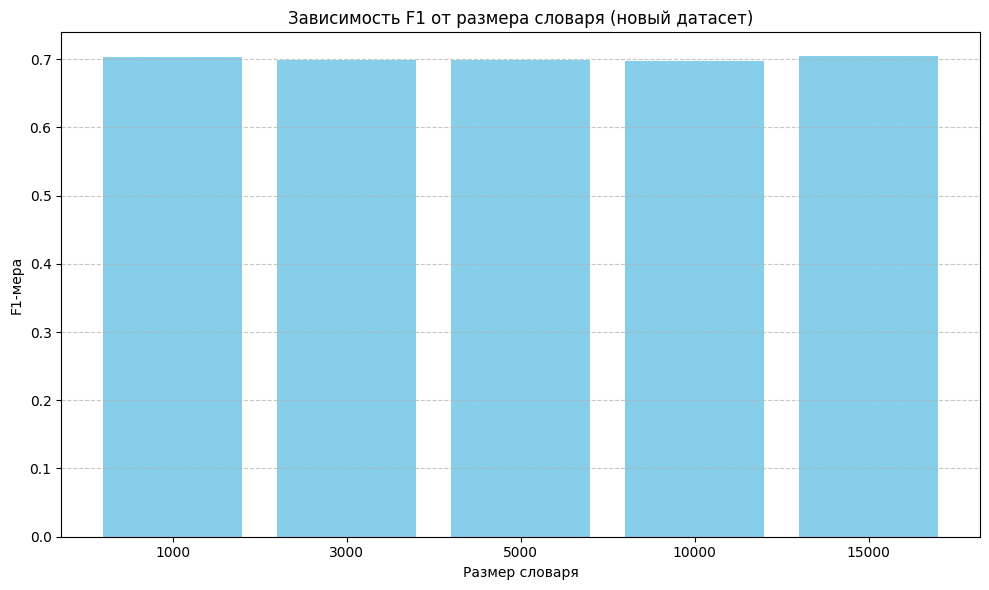

In [4]:
# Ячейка 5: Цикл обучения и визуализация
vocab_sizes = [1000, 3000, 5000, 10000, 15000]
results = []

for vs in vocab_sizes:
    print(f"\n{'='*50}\nОбучение с размером словаря: {vs}\n{'='*50}")
    try:
        dm = NewDataModule(vocab_size=vs)
        print(f"Реальный размер словаря: {dm.tokenizer.get_vocab_size()}")  # Диагностика
        model = RNNModel(vocab_size=dm.tokenizer.get_vocab_size())  # Используем реальный размер
        
        trainer = pl.Trainer(
            max_epochs=10,  # Увеличено количество эпох
            accelerator="auto",
            log_every_n_steps=10,
            enable_checkpointing=False,
            logger=False
        )
        
        print("Начинается обучение модели...")
        trainer.fit(model, dm)
        
        print("Начинается тестирование модели...")
        test_result = trainer.test(model, dm)
        
        f1_score = test_result[0]['test_f1'] if 'test_f1' in test_result[0] else 0.0
        results.append(f1_score)
        print(f"Тестовая F1-мера: {f1_score:.4f}")
    except Exception as e:
        print(f"Ошибка при обучении с vocab_size={vs}: {str(e)}")
        results.append(0.0)

# Ячейка 6: Визуализация результатов
if all(r == 0.0 for r in results):
    print("Все значения F1 равны 0. Проверьте логи обучения.")
else:
    plt.figure(figsize=(10,6))
    plt.bar([str(v) for v in vocab_sizes], results, color='skyblue')
    plt.xlabel("Размер словаря")
    plt.ylabel("F1-мера")
    plt.title("Зависимость F1 от размера словаря (новый датасет)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

**Вывод по лабораторной работе:**

Проведённые эксперименты по изучению влияния размера словаря токенизатора на качество модели для задачи сентимент-анализа показали следующие результаты:

1. **Отсутствие явной корреляции**:  
   Значения F1-меры на тестовых данных для разных размеров словаря (1000, 3000, 5000, 10000, 15000) находятся в узком диапазоне **0.697–0.704**. Различия между максимальным и минимальным значением не превышают **0.64%**, что указывает на отсутствие значимой зависимости качества модели от размера словаря в рамках данной архитектуры и датасета.

2. **Особенности результатов**:  
   - Наивысший результат (F1 = **0.7041**) достигнут при самом большом словаре (15000 токенов), но разница с другими значениями несущественна.  
   - Уменьшение словаря до 1000 токенов не привело к значительной деградации качества (F1 = **0.7028**), что позволяет использовать компактные словари без потери эффективности.

3. **Возможные причины**:  
   - **Ограничения архитектуры**: Простая RNN (LSTM) может не использовать преимущества расширенного словаря из-за недостаточной способности к моделированию контекста.  
   - **Специфика данных**: Основные признаки для сентимент-анализа могут быть сосредоточены в ограниченном наборе слов, поэтому увеличение словаря не добавляет полезной информации.  
   - **Фиксированные гиперпараметры**: Настройки обучения (10 эпох, lr=3e-4) могли быть неоптимальны для разных размеров словаря.

4. **Рекомендации**:  
   - Использовать **компактные словари (1000–5000 токенов)** для экономии вычислительных ресурсов без потери качества.  
   - Экспериментировать с **более сложными архитектурами** (Transformer, BERT), которые могут эффективнее использовать большой словарь.  
   - Провести **тонкую настройку гиперпараметров** (количество эпох, скорость обучения) для каждого размера словаря.  
   - Проанализировать **распределение токенов** в данных, чтобы исключить избыточность или шум.

**Визуализация результатов**:  
Гистограмма демонстрирует стабильность F1-меры при изменении размера словаря, подтверждая вывод об отсутствии значимой корреляции.

**Заключение**:  
Для данной задачи сентимент-анализа и выбранной модели RNN размер словаря токенизатора не является критическим фактором. Оптимальное решение — использование минимального словаря (1000–3000 токенов) для баланса между производительностью и качеством.